# 데이터 및 패키지 로딩

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

In [ ]:
import os
import urllib.request

path_to_file = 'sherlock.txt'
if not os.path.exists(path_to_file):
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/hyerica-bdml/class-2026-nlp/refs/heads/main/data/sherlock.txt',
        path_to_file)

with open(path_to_file) as f:
    lines = f.read().splitlines()

In [ ]:
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('punkt_tab')
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to /root/nltk_data...


# 학습 데이터 준비

생성 데이터
* vocab: 단어 -> ID
* inverse_vocab: ID -> 단어
* input_targets: 타깃 주변 단어 ID의 배열
* input_centers: 중심 단어 ID의 배열

In [ ]:
vocab, index = {}, 1  # start indexing from 1
vocab['<pad>'] = 0  # add a padding token
preprocessed_tokens = []

for sentence in lines:
    tokens = [lemmatizer.lemmatize(token.lower(), pos = "v")
              for token in nltk.tokenize.word_tokenize(sentence)
              if token.isalpha()]
    preprocessed_tokens.append(tokens)

    for token in tokens:
        if token not in vocab:
            vocab[token] = index
            index += 1

inverse_vocab = {index: token for token, index in vocab.items()}
vocab_size = len(vocab)
print(vocab_size)

4477


In [7]:
sequences = []
for tokens in preprocessed_tokens:
    seq = [vocab[token] for token in tokens]
    sequences.append(seq)

In [ ]:
def skipgrams_with_negatives(sequence, vocab_size, window_size, negative_samples=1., rng=None):
    ## --- fill here ---

In [ ]:
targets, centers, pos_or_neg = [], [], []

rng = np.random.default_rng(seed=42)
window_size = 2
for sequence in sequences:
    skip_grams, labels = skipgrams_with_negatives(
        sequence, vocab_size, window_size=window_size, negative_samples=1., rng=rng)

    if len(skip_grams) < 2:
        continue

    _targets, _centers = zip(*skip_grams)
    targets.extend(_targets)
    centers.extend(_centers)
    pos_or_neg.extend(labels)

In [ ]:
input_targets = np.array(targets)
input_centers = np.array(centers)
input_labels  = np.array(pos_or_neg, dtype=np.float32)

# 모델 정의

* Word2VecNegativeSampling: 주변단어 가중치 U 및 임베딩 벡터 V의 모델 파라미터를 포함한 로스 계산 모듈

In [ ]:
hidden_dim = 32

class Word2VecNegativeSampling(nn.Module):
    ## --- fill here ---

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Word2VecNegativeSampling(vocab_size, hidden_dim).to(device)
optimizer = torch.optim.Adam(model.parameters())
print(model)

Word2VecNegativeSampling(
  (center_embedding): Embedding(4477, 32)
  (target_embedding): Embedding(4477, 32)
)


# 학습

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

centers_tensor = torch.tensor(input_centers, dtype=torch.long)
targets_tensor = torch.tensor(input_targets, dtype=torch.long)
labels_tensor  = torch.tensor(input_labels, dtype=torch.float32)

dataset = TensorDataset(centers_tensor, targets_tensor, labels_tensor)
loader = DataLoader(dataset, batch_size=100, shuffle=True)

epochs = 20
model.train()
for epoch in range(epochs):
    total_loss = 0.0
    for batch_centers, batch_targets, batch_labels in loader:
        ## --- fill here ---

        total_loss += loss.item()

    print(f"Epoch {epoch + 1}/{epochs} - loss: {total_loss / len(loader):.4f}")

Epoch 1/20 - loss: 1.8677
Epoch 2/20 - loss: 1.2837
Epoch 3/20 - loss: 0.9543
Epoch 4/20 - loss: 0.7287
Epoch 5/20 - loss: 0.5684
Epoch 6/20 - loss: 0.4602
Epoch 7/20 - loss: 0.3904
Epoch 8/20 - loss: 0.3453
Epoch 9/20 - loss: 0.3150
Epoch 10/20 - loss: 0.2936
Epoch 11/20 - loss: 0.2776
Epoch 12/20 - loss: 0.2648
Epoch 13/20 - loss: 0.2542
Epoch 14/20 - loss: 0.2449
Epoch 15/20 - loss: 0.2365
Epoch 16/20 - loss: 0.2287
Epoch 17/20 - loss: 0.2214
Epoch 18/20 - loss: 0.2146
Epoch 19/20 - loss: 0.2080
Epoch 20/20 - loss: 0.2019


In [13]:
model.eval()

def get_embeddings(word_ids):
    with torch.no_grad():
        ids = torch.tensor(word_ids, dtype=torch.long, device=device)
        return model.center_embedding(ids).cpu().numpy()

In [14]:
first_500_words = np.arange(500)
final_embeddings = get_embeddings(first_500_words)
final_embeddings.shape

(500, 32)

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


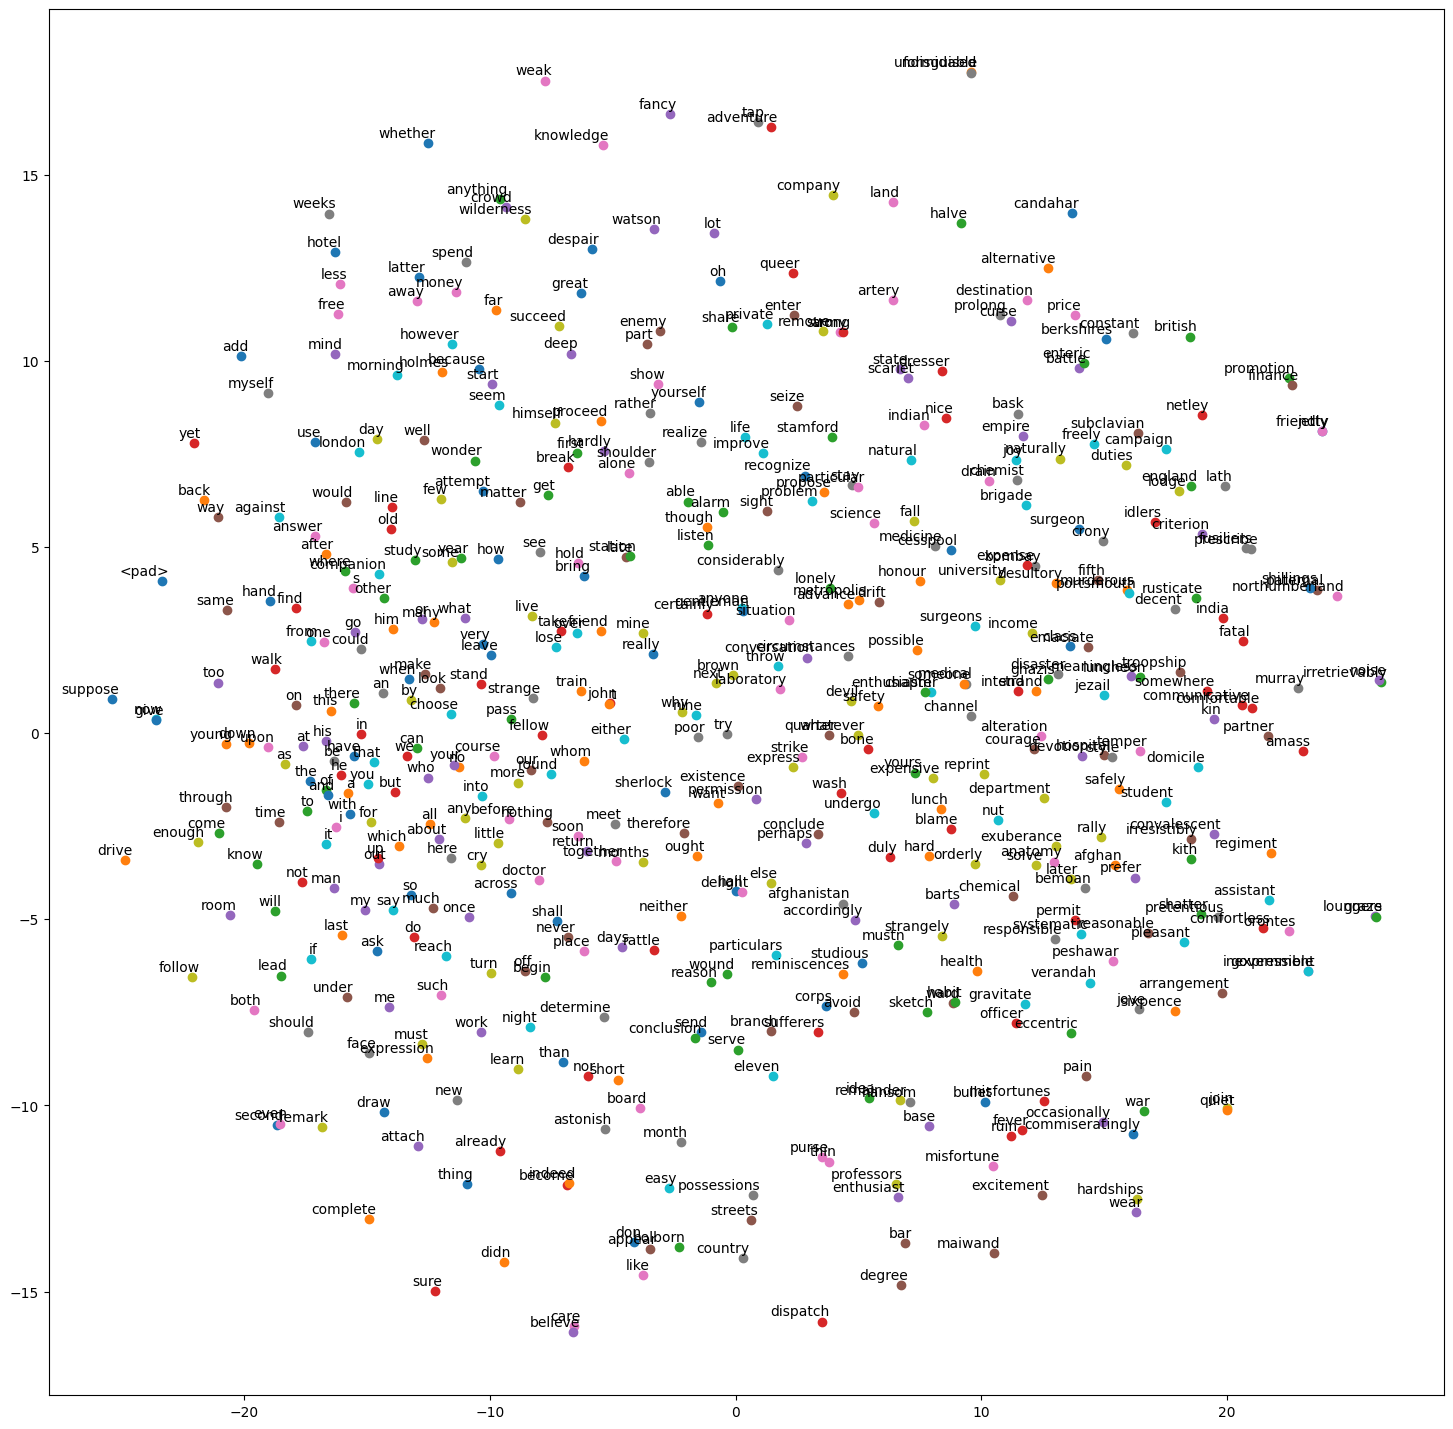

In [15]:
def plot_with_labels(low_dim_embs, labels):
    assert low_dim_embs.shape[0] >= len(
        labels), 'More labels than embeddings'
    plt.figure(figsize=(18, 18))  # in inches
    for i, label in enumerate(labels):
        x, y = low_dim_embs[i, :]
        plt.scatter(x, y)
        plt.annotate(label,
                     xy=(x, y),
                     xytext=(5, 2),
                     textcoords='offset points',
                     ha='right',
                     va='bottom')
    plt.show()


from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(perplexity=30, n_components=2,
            init='pca', method='exact')
n_embeddings = 500
low_dim_embeddings = tsne.fit_transform(final_embeddings)
labels = [inverse_vocab[i] for i in range(n_embeddings)]

plot_with_labels(low_dim_embeddings, labels)